<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;">

<h1 style="margin-bottom:0;"><b> Machine Learning II </b></h1>


# Customer Segmentation - Clustering Notebook

This notebook applies and compares clustering techniques for customer segmentation. It includes K-Means model selection, final segment profiling, PCA/t-SNE/UMAP visual validation, SOM exploratory analysis, hierarchical clustering, density-based alternatives, outlier assignment and final export files.

<a id="section-1-imports-and-data-loading"></a>
<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;">
<h3><b>1. Imports and Data Loading</b></h3>
</div>

In [1]:
import os
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN, MeanShift, estimate_bandwidth
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from scipy.cluster.hierarchy import dendrogram, linkage

import utils_clustering as clu

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")


In [2]:
import importlib
importlib.reload(clu)

<module 'utils_clustering' from '/Users/franciscateixeira/Documents/ML/CostumerSegP_MLII/clustering/utils_clustering.py'>

In [5]:
selected_features = [
    "number_complaints",
    "distinct_stores_visited",
    "percentage_of_products_bought_promotion",
    "customer_age",
    "tenure",
    "total_children",
    "is_male",
    "customer_loyalty_flag",
    "typical_hour_sin",
    "typical_hour_cos",
    "latitude",
    "longitude",
    "education_level",
    "total_spend",
    "pct_spend_groceries",
    "pct_spend_vegetables",
    "pct_spend_nonalcohol_drinks",
    "pct_spend_alcohol_drinks",
    "pct_spend_meat",
    "pct_spend_fish",
    "pct_spend_hygiene",
    "pct_spend_petfood",
    "pct_spend_technology",
]


X, df = clu.load_clustering_data(
    "../datasets/info_clustering_ready.csv", 
    selected_features
)

clu.validate_clustering_input(X)

X.head()

Dataset shape: (32047, 23)
Features used: 23
Input validation passed successfully.


,number_complaints,distinct_stores_visited,percentage_of_products_bought_promotion,customer_age,tenure,total_children,is_male,customer_loyalty_flag,typical_hour_sin,typical_hour_cos,...,total_spend,pct_spend_groceries,pct_spend_vegetables,pct_spend_nonalcohol_drinks,pct_spend_alcohol_drinks,pct_spend_meat,pct_spend_fish,pct_spend_hygiene,pct_spend_petfood,pct_spend_technology
0,0.0,0.0,1.049200,0.032258,-0.833333,0.0,0,1,0.007571,0.387135,...,-0.120778,-0.328215,-0.037259,-0.098118,-0.425625,-0.948961,-0.425489,-0.037600,0.383979,1.474190
1,-1.0,-0.5,-0.311186,-0.161290,0.333333,-1.0,0,1,-0.108516,-0.394586,...,-0.006007,-0.109754,1.632679,0.443032,-0.583949,-0.929306,-0.800456,1.682070,1.238171,-0.206544
2,-1.0,-0.5,-0.539272,-0.032258,1.666667,-2.0,1,0,0.189469,-0.767327,...,-0.333205,0.468239,0.291546,-0.754589,-0.489018,1.586341,-0.212063,0.041638,-0.062242,-0.703580
3,1.0,-1.0,-0.018274,-0.387097,-1.000000,-2.0,1,1,-0.732051,0.823443,...,-0.374908,-0.948143,-0.341187,1.908452,1.747981,1.067286,1.707989,0.037028,-0.200149,0.834914
4,2.0,-1.0,-0.207602,0.032258,-1.000000,-2.0,1,1,-0.707107,0.397198,...,0.382662,-1.640176,-0.149479,0.238192,0.175117,0.317712,0.550307,-0.532100,0.134857,3.290386


<a id="section-1-imports-and-data-loading"></a>
<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;">
<h3><b>2. K-Means: Choosing the Number of Clusters</b></h3>
</div>

K-Means was tested for different values of `k`. The Elbow Method helps understand how inertia decreases as more clusters are added, while the Silhouette Score measures the average separation and cohesion of the clusters.

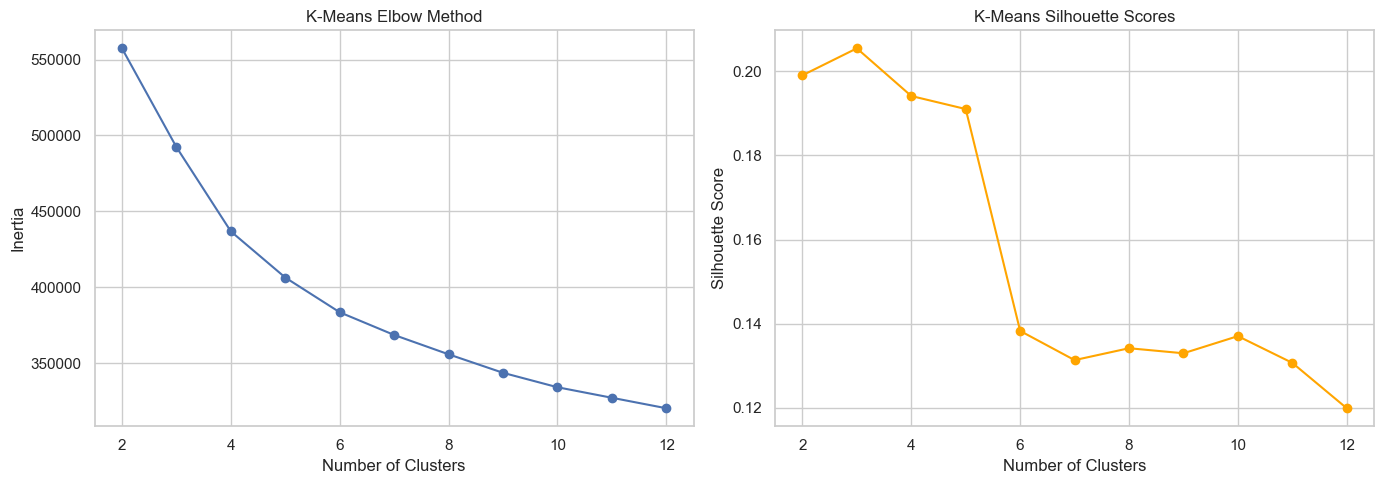

In [6]:
# Evaluate multiple k values using utils function
kmeans_results = clu.evaluate_multiple_kmeans(X, k_range=range(2, 13), random_state=42)
kmeans_results

clu.plot_elbow_and_silhouette(kmeans_results)

In [7]:
kmeans_comparison = clu.compare_kmeans_models(
    X, df, 
    k_values=[3, 4, 5, 6, 7], 
    random_state=42
)

# Access individual results if needed
k3_model = kmeans_comparison[3]["model"]
k3_labels = kmeans_comparison[3]["labels"]
k3_profile = kmeans_comparison[3]["profile"]
k3_metrics = kmeans_comparison[3]["metrics"]

--- KMEANS k=3 ---

Cluster distribution:
0     3018
1     6158
2    22871
Name: count, dtype: int64

Metrics:
        Model  Clusters  Silhouette Score
0  KMeans k=3         3          0.205473

--------------------------------------------------
--- KMEANS k=4 ---

Cluster distribution:
0     2966
1     6351
2     3617
3    19113
Name: count, dtype: int64

Metrics:
        Model  Clusters  Silhouette Score
0  KMeans k=4         4          0.194137

--------------------------------------------------
--- KMEANS k=5 ---

Cluster distribution:
0     2888
1     3306
2    17578
3     5591
4     2684
Name: count, dtype: int64

Metrics:
        Model  Clusters  Silhouette Score
0  KMeans k=5         5          0.191034

--------------------------------------------------
--- KMEANS k=6 ---

Cluster distribution:
0     7415
1    11578
2     4901
3     3243
4     2171
5     2739
Name: count, dtype: int64

Metrics:
        Model  Clusters  Silhouette Score
0  KMeans k=6         6          0.13826

<a id="section-1-imports-and-data-loading"></a>
<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;">
<h3><b>4. Final K-Means Model</b></h3>
</div>



K-Means with `k=5` was selected because it provides a stronger segmentation structure than `k=3`, while still keeping acceptable separation and interpretability. This solution gives more actionable customer groups without fragmenting the population excessively.

In [8]:
best_k = 4

kmeans_model, kmeans_labels = clu.train_kmeans_final(X, n_clusters=best_k, random_state=42)

customer_info_kmeans = df.copy()
customer_info_kmeans["kmeans_cluster"] = kmeans_labels

In [9]:
cluster_dist = clu.cluster_distribution(kmeans_labels)
print("Cluster distribution:")
print(cluster_dist)

Cluster distribution:
0     2966
1     6351
2     3617
3    19113
Name: count, dtype: int64


In [10]:
kmeans_metrics = clu.evaluate_clustering(X, kmeans_labels, model_name=f"KMeans k={best_k}")
kmeans_metrics

kmeans_profile = clu.create_cluster_profile(customer_info_kmeans, cluster_col="kmeans_cluster")
kmeans_profile

,cluster_size,cluster_percentage,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_vegetables,lifetime_spend_nonalcohol_drinks,lifetime_spend_alcohol_drinks,lifetime_spend_meat,lifetime_spend_fish,...,pct_spend_nonalcohol_drinks,pct_spend_alcohol_drinks,pct_spend_meat,pct_spend_fish,pct_spend_hygiene,pct_spend_petfood,pct_spend_technology,customer_loyalty_flag,is_male,education_level
kmeans_cluster,,,,,,,,,,,,,,,,,,,,,
0,2966,9.26,-0.01,0.10,0.99,0.38,0.92,1.43,1.09,1.03,...,0.24,0.64,0.34,0.47,-0.12,-0.31,0.54,0.68,0.51,1.15
1,6351,19.82,-0.31,0.26,-0.44,1.14,0.22,-0.24,-0.66,-0.37,...,1.26,0.17,-0.01,-0.04,1.87,1.09,0.30,0.62,0.51,1.34
2,3617,11.29,0.04,-0.66,-0.43,-0.33,0.30,0.89,0.24,0.46,...,0.47,1.04,0.42,0.66,-0.41,0.01,3.07,0.47,0.47,0.11
3,19113,59.64,-0.04,0.17,0.51,0.13,-0.10,0.03,-0.01,0.10,...,-0.17,0.01,0.10,0.06,0.02,0.06,-0.11,0.61,0.50,0.90


<a id="section-1-imports-and-data-loading"></a>
<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;">
<h3><b>5. Silhouette Analysis</b></h3>
</div>



The silhouette plot shows how well each customer fits within its assigned cluster compared with the nearest alternative cluster. In customer segmentation, moderate silhouette values are common because real customer behavior is complex and overlapping.

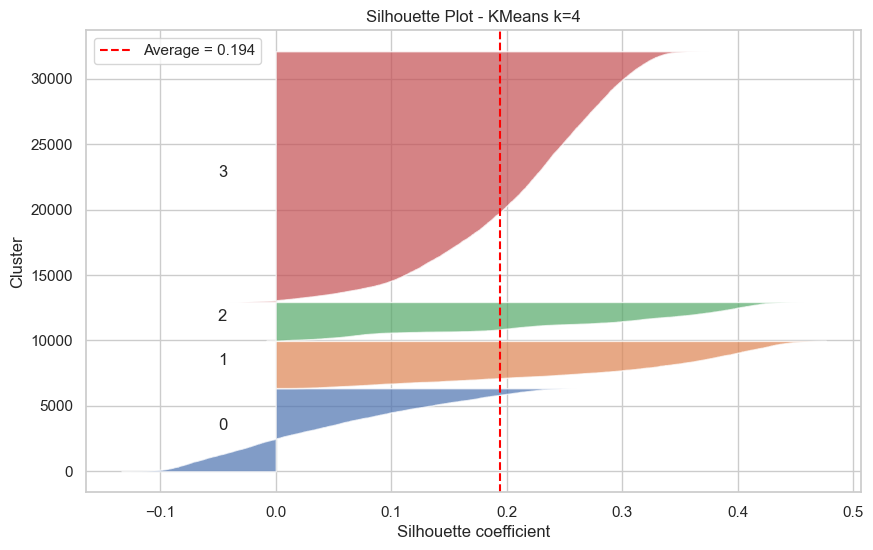

In [9]:
clu.plot_silhouette_analysis(
    X,
    kmeans_labels,
    title="Silhouette Plot - KMeans k=4"
)

In [11]:
top_cluster_features = clu.get_top_cluster_features(
    kmeans_profile,
    top_n=5
)

top_cluster_features

,cluster,top_positive_features,top_negative_features
0,0,"[pct_spend_vegetables, pct_spend_hygiene, educ...","[tenure, total_children, number_complaints, to..."
1,1,"[pct_spend_technology, pct_spend_alcohol_drink...","[longitude, pct_spend_hygiene, distinct_stores..."
2,2,"[total_children, total_spend, education_level,...","[longitude, number_complaints, pct_spend_hygie..."
3,3,"[education_level, customer_loyalty_flag, is_ma...","[customer_age, number_complaints, pct_spend_te..."


## 10. PCA, t-SNE and UMAP Visualizations

Dimensionality reduction techniques are used only for visualization. They help assess whether the final K-Means segments show coherent separation in lower-dimensional spaces.

Explained variance with 2 components: 0.3372


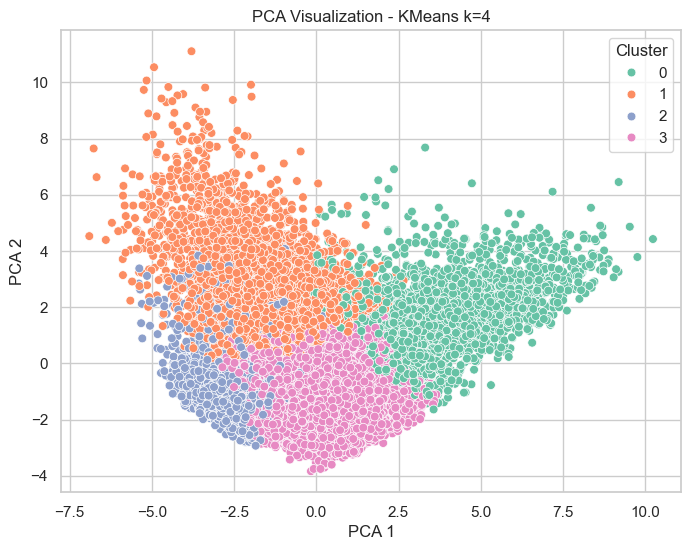

In [11]:
embedding, pca_model = clu.plot_pca_clusters(
    X,
    kmeans_labels,
    title="PCA Visualization - KMeans k=4"
)

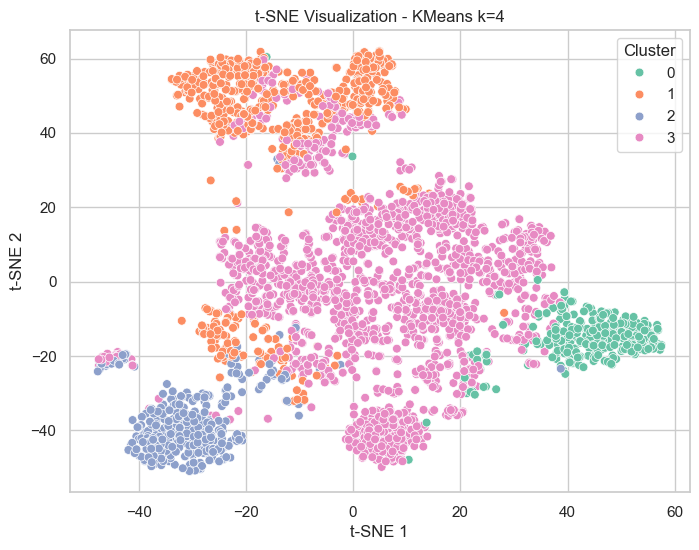

In [12]:
tsne_embedding = clu.plot_tsne_clusters(
    X, 
    kmeans_labels, 
    title="t-SNE Visualization - KMeans k=4",
    sample_size=3000, 
    perplexity=30, 
    random_state=42
)

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


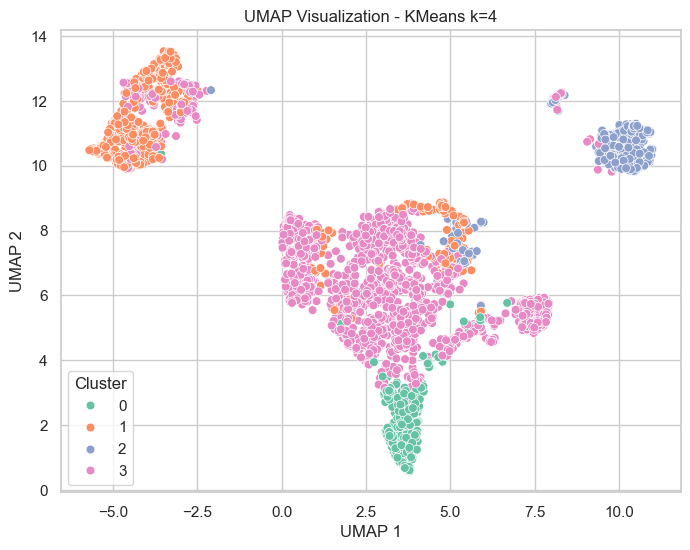

In [13]:
umap_embedding = clu.plot_umap_clusters(
    X, 
    kmeans_labels, 
    title="UMAP Visualization - KMeans k=4",
    sample_size=3000, 
    n_neighbors=15, 
    min_dist=0.1, 
    random_state=42
)

## 11. Self-Organizing Map (SOM) Insights

A Self-Organizing Map was used as an additional exploratory tool. Unlike K-Means, the SOM is not used here as the final clustering model. Instead, it helps visualize the structure of the customer space and inspect how important features vary across the map.

Using sample of 8000 points for SOM training
Mean quantization error: 0.5689
Median quantization error: 0.5564


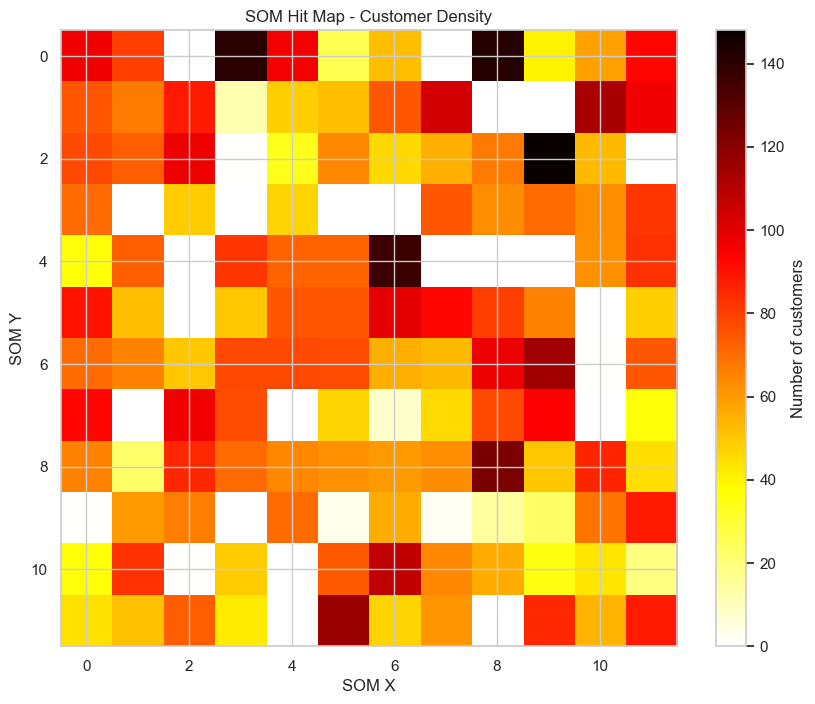

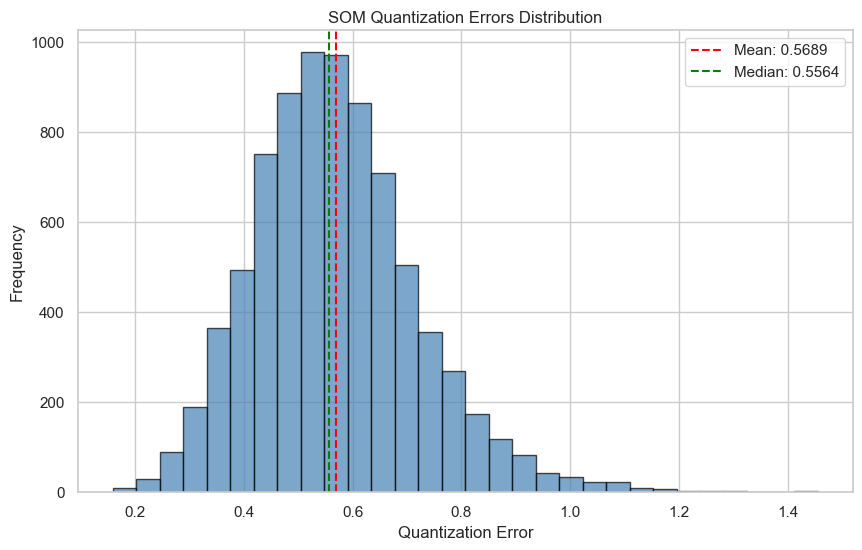

In [19]:
som_weights, som_bmus, som_errors = clu.train_som(
    X,
    grid_size=(12, 12),
    n_iterations=2500,
    learning_rate=0.5,
    random_state=42,
    sample_size=8000
)

print(f"Mean quantization error: {som_errors.mean():.4f}")
print(f"Median quantization error: {np.median(som_errors):.4f}")

som_hit_map = clu.plot_som_hit_map(
    som_bmus,
    grid_size=(12, 12),
    title="SOM Hit Map - Customer Density"
)

clu.plot_som_quantization_errors(som_errors)

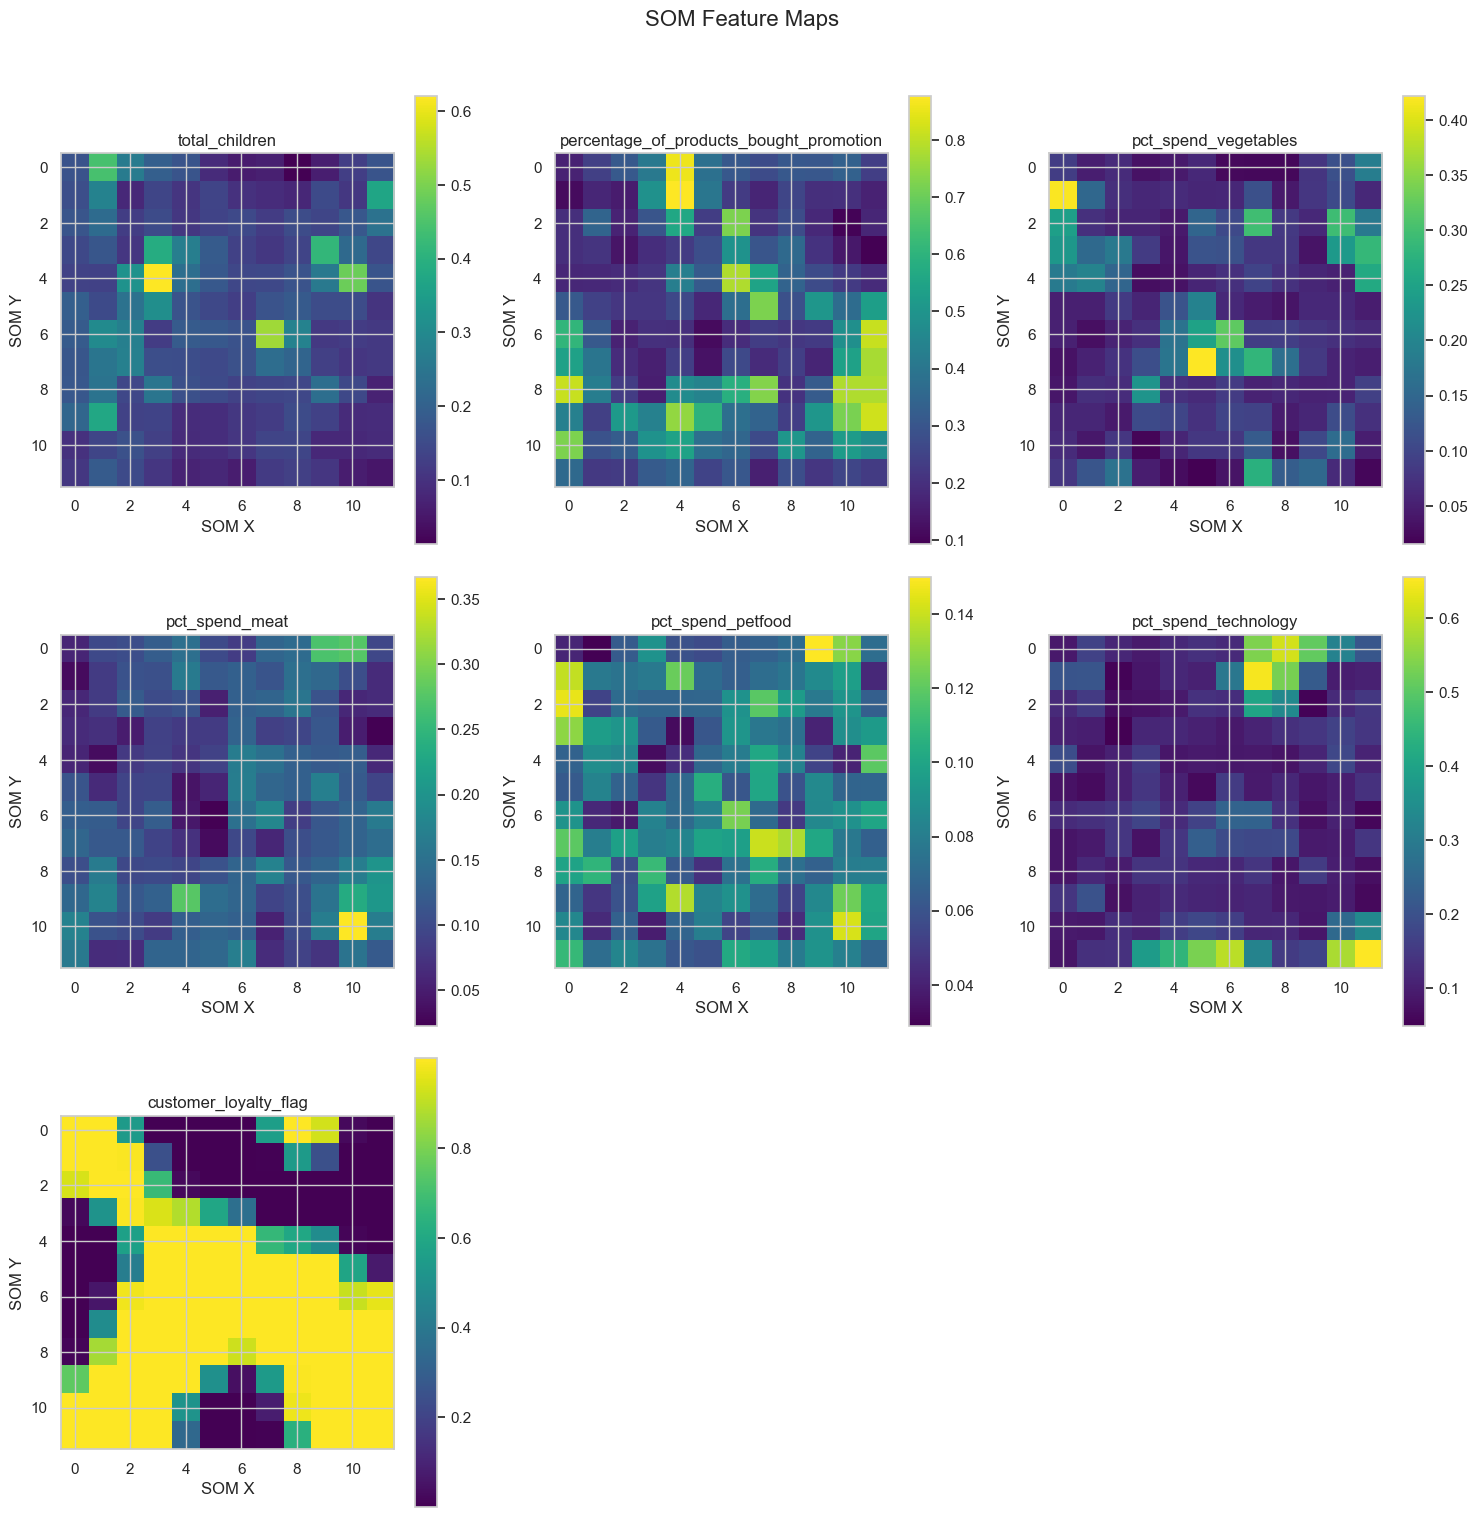

In [21]:
som_features = [
    "total_children",
    "percentage_of_products_bought_promotion",
    "pct_spend_vegetables",
    "pct_spend_meat",
    "pct_spend_petfood",
    "pct_spend_technology",
    "customer_loyalty_flag"
]

clu.plot_som_feature_maps(
    som_weights,
    feature_names=list(X.columns),
    selected_features=som_features,
    grid_size=(12, 12)
)

## 12. Hierarchical Clustering

Hierarchical clustering was tested as an alternative method to validate whether a similar segmentation structure could be found using a different clustering approach.

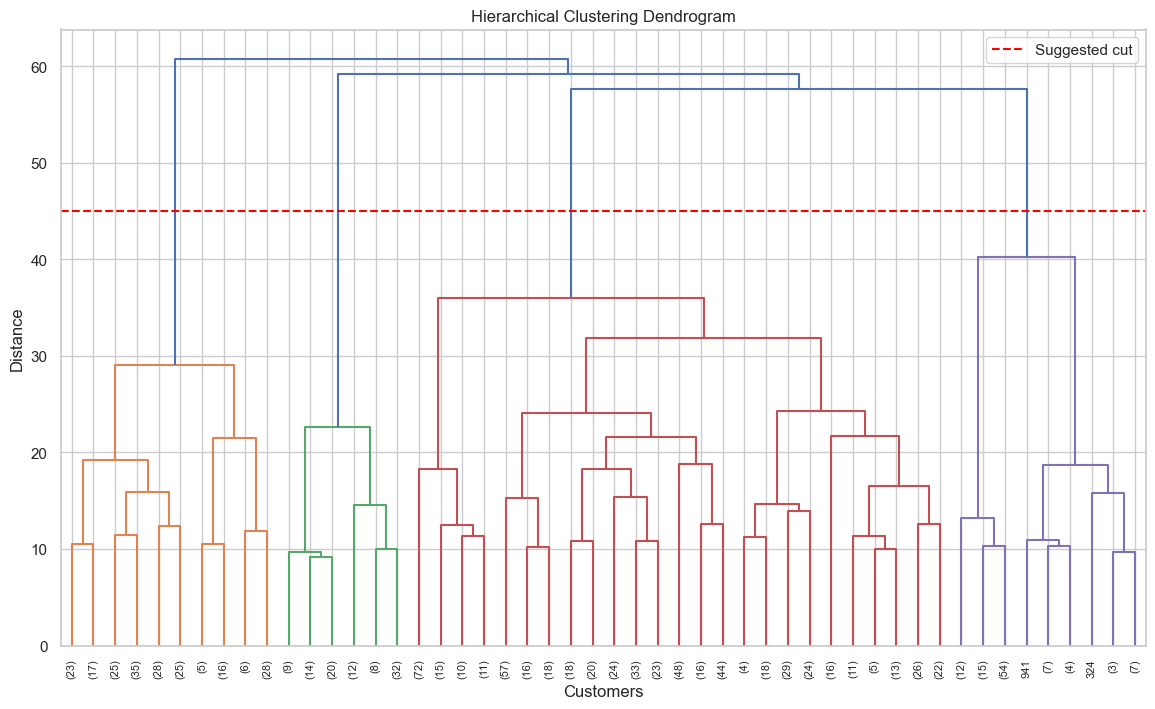

In [47]:
linkage_matrix = clu.plot_dendrogram_sample(
    X, 
    sample_size=1000, 
    method="ward", 
    truncate_p=50, 
    cut_line=45,
    random_state=42
)

The dendrogram suggests a reasonable partition around five groups, supporting the `k=4` segmentation used in the final K-Means model.

Cluster distribution:
0     8924
1    16948
2     3102
3     3073
Name: count, dtype: int64
Explained variance with 2 components: 0.3372


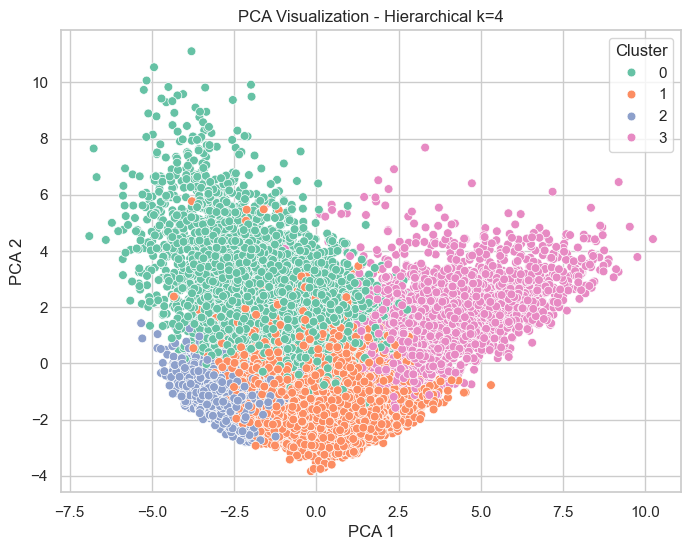

In [22]:
hier_results = clu.run_hierarchical_clustering(X, n_clusters=4, linkage_method="ward")

hier_labels = hier_results["labels"]
hier_model = hier_results["model"]
hier_metrics = hier_results["metrics"]
hier_distribution = hier_results["cluster_distribution"]

customer_info_hier = df.copy()
customer_info_hier["hierarchical_cluster"] = hier_labels

print("Cluster distribution:")
print(hier_distribution)

hier_metrics

_ = clu.plot_pca_clusters(
    X,
    hier_labels,
    title="PCA Visualization - Hierarchical k=4"
)

In [30]:
hier_metrics = clu.evaluate_clustering(
    X,
    hier_labels,
    model_name="Hierarchical k=4"
)

hier_metrics

,Model,Clusters,Silhouette Score
0,Hierarchical k=4,4,0.156254


## 13. K-Means vs Hierarchical Agreement

This heatmap compares the final K-Means solution with the Hierarchical Clustering solution. Strong concentration in specific cells indicates that the methods identify similar structures.

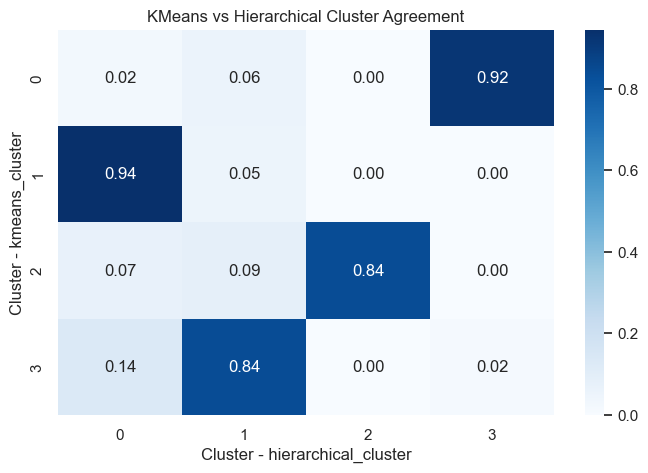

hierarchical_cluster,0,1,2,3
kmeans_cluster,,,,
0,0.02,0.06,0.00,0.92
1,0.94,0.05,0.00,0.00
2,0.07,0.09,0.84,0.00
3,0.14,0.84,0.00,0.02


In [23]:
cluster_agreement = clu.plot_cluster_agreement_heatmap(
    customer_info_kmeans.assign(hierarchical_cluster=hier_labels),
    col1="kmeans_cluster",
    col2="hierarchical_cluster",
    title="KMeans vs Hierarchical Cluster Agreement"
)

cluster_agreement.round(2)

## 14. DBSCAN

DBSCAN was tested as a density-based clustering method. It is useful when clusters have clear density separation, but it can struggle with high-dimensional customer datasets and heterogeneous densities.

Cluster distribution:
-1    29148
 0     1442
 1     1278
 2        8
 3       90
 4       11
 5       21
 6       18
 7       12
 8       10
 9        9
Name: count, dtype: int64
Explained variance with 2 components: 0.3372


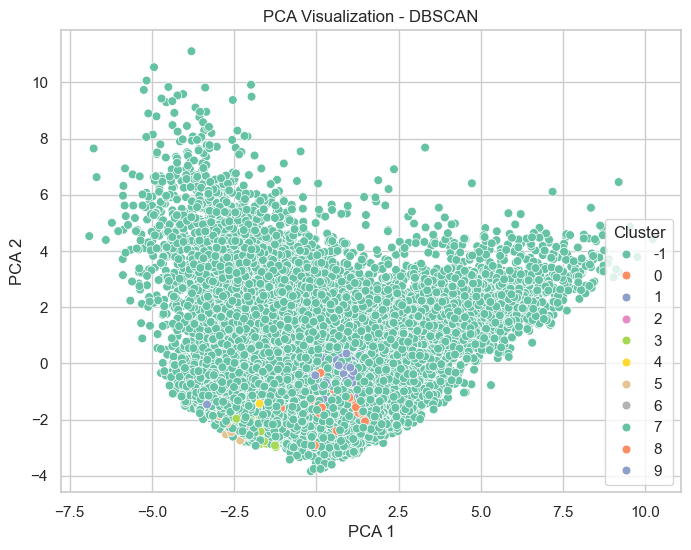

In [24]:
dbscan_results = clu.run_dbscan_analysis(X, eps=1.5, min_samples=10, title="DBSCAN")

dbscan_labels = dbscan_results["labels"]
dbscan_model = dbscan_results["model"]
dbscan_metrics = dbscan_results["metrics"]
dbscan_distribution = dbscan_results["cluster_distribution"]

customer_info_dbscan = df.copy()
customer_info_dbscan["dbscan_cluster"] = dbscan_labels

print("Cluster distribution:")
print(dbscan_distribution)

dbscan_metrics

_ = clu.plot_pca_clusters(
    X,
    dbscan_labels,
    title="PCA Visualization - DBSCAN"
)

## 15. Mean Shift

Mean Shift was also tested as a density-based method. Because it can be computationally expensive, it was evaluated on a sample of the dataset.

Using sample of 5000 points for Mean Shift
Estimated bandwidth: 4.9946
Bandwidth: 4.9946

Cluster distribution:
0    4937
1       4
2      34
3      14
4      11
Name: count, dtype: int64
Explained variance with 2 components: 0.3432


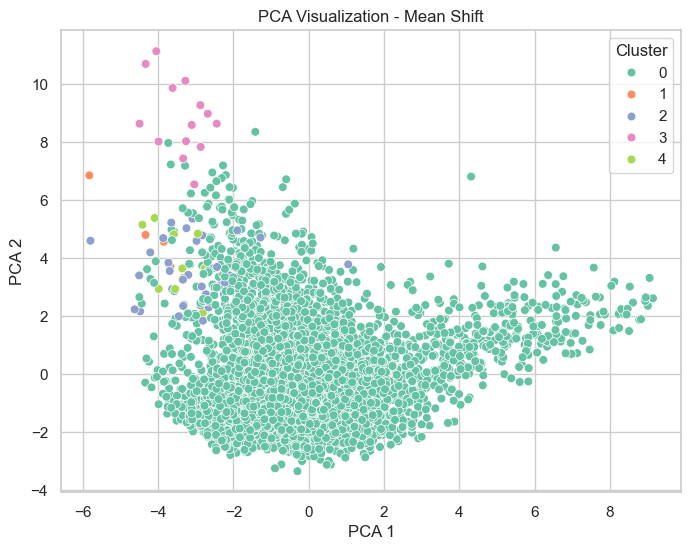

In [25]:
meanshift_results = clu.run_meanshift_analysis(
    X, 
    sample_size=5000, 
    quantile=0.2, 
    bin_seeding=True, 
    random_state=42
)

meanshift_labels = meanshift_results["labels"]
meanshift_model = meanshift_results["model"]
meanshift_metrics = meanshift_results["metrics"]
bandwidth = meanshift_results["bandwidth"]
meanshift_distribution = meanshift_results["cluster_distribution"]
X_meanshift_sample = meanshift_results["sample_used"]

print(f"Bandwidth: {bandwidth:.4f}")
print("\nCluster distribution:")
print(meanshift_distribution)

meanshift_metrics

_ = clu.plot_pca_clusters(
    X_meanshift_sample,
    meanshift_labels,
    title="PCA Visualization - Mean Shift"
)

In [38]:
meanshift_metrics = clu.evaluate_clustering(
    X_meanshift_sample,
    meanshift_labels,
    model_name="Mean Shift"
)

meanshift_metrics

,Model,Clusters,Silhouette Score
0,Mean Shift,5,0.34097


## 16. Model Comparison

The final model comparison uses Silhouette Score as the quantitative metric. However, model selection also considers interpretability, cluster size balance and usefulness for customer segmentation.

In [40]:
comparison = pd.concat(
    [
        kmeans_metrics,
        hier_metrics,
        dbscan_metrics,
        meanshift_metrics
    ],
    ignore_index=True
)

comparison

,Model,Clusters,Silhouette Score
0,KMeans k=4,4,0.194285
1,Hierarchical k=4,4,0.156254
2,DBSCAN,10,-0.265110
3,Mean Shift,5,0.340970


### Why K-Means Was Selected

K-Means with `k=5` was selected as the final model because it provided the best balance between statistical performance, visual separation and business interpretability.

Although Mean Shift may produce a higher silhouette score, it assigns most observations to one dominant cluster, which makes it less useful for customer segmentation. DBSCAN was not selected because it produced weak separation and many noisy observations. Hierarchical clustering was useful as a comparison method, but K-Means produced clearer and more actionable final segments.

## 17. Optional: Assign Removed Outliers to the Nearest K-Means Centroid

During preprocessing, extreme spenders were stored separately so they would not distort the clustering model. After the final K-Means model is trained, these customers can be assigned to the closest existing centroid.

This step is only executed if the outlier dataset has the same clustering features as the model input. If the columns are not aligned, the notebook skips the assignment to avoid an incorrect result.

In [41]:
outlier_path = "../datasets/outlier_dataset.csv"

if os.path.exists(outlier_path):
    outlier_dataset = pd.read_csv(outlier_path)

    try:
        assigned_outliers = clu.assign_outliers_to_nearest_centroid(
            outlier_dataset,
            feature_columns=X.columns,
            kmeans_model=kmeans_model,
            cluster_col="kmeans_cluster"
        )

        assigned_outliers, _ = clu.add_segment_names(
            assigned_outliers,
            cluster_col="kmeans_cluster",
            name_col="segment_name"
        )

        assigned_outliers = clu.add_recommendations(
            assigned_outliers,
            name_col="segment_name",
            action_col="recommended_action"
        )

        final_clustered_dataset = pd.concat(
            [customer_info_kmeans, assigned_outliers],
            ignore_index=True
        )

        print("Outliers assigned successfully.")
        print("Final dataset shape:", final_clustered_dataset.shape)

    except ValueError as error:
        print("Outlier assignment skipped:")
        print(error)
        final_clustered_dataset = customer_info_kmeans.copy()
else:
    print("Outlier dataset not found. Continuing with the main clustered dataset only.")
    final_clustered_dataset = customer_info_kmeans.copy()

Outliers assigned successfully.
Final dataset shape: (32208, 42)


## 18. Segment-Based Business Recommendations

After naming the final clusters, simple business actions were assigned to each segment. These recommendations are based on the cluster profile and should support later marketing and basket-analysis work.

In [42]:
customer_info_kmeans = clu.add_recommendations(
    customer_info_kmeans,
    name_col="segment_name",
    action_col="recommended_action"
)

segment_recommendations = (
    customer_info_kmeans[["segment_name", "recommended_action"]]
    .drop_duplicates()
    .sort_values("segment_name")
)

segment_recommendations

,segment_name,recommended_action
3,Healthy Lifestyle Buyers,"Promote fresh produce, hygiene products, welln..."
26,Premium Grocery & Pet Buyers,"Use cross-category bundles involving meat, fis..."
1,Promotion-Oriented Regulars,"Use discount campaigns, personalized coupons, ..."
0,Tech-Focused Customers,"Target with technology offers, new product lau..."


In [43]:
customer_info_kmeans[[
    "customer_id",
    "kmeans_cluster",
    "segment_name",
    "recommended_action"
]].head()

,customer_id,kmeans_cluster,segment_name,recommended_action
0,3,3,Tech-Focused Customers,"Target with technology offers, new product lau..."
1,4,0,Promotion-Oriented Regulars,"Use discount campaigns, personalized coupons, ..."
2,5,3,Tech-Focused Customers,"Target with technology offers, new product lau..."
3,7,1,Healthy Lifestyle Buyers,"Promote fresh produce, hygiene products, welln..."
4,8,1,Healthy Lifestyle Buyers,"Promote fresh produce, hygiene products, welln..."


## 19. Export Final Results

The final outputs are exported for later use in cluster characterization, basket analysis and marketing strategy.

In [44]:
# Ensure customer_id is stored as an integer identifier when possible
for _df in [customer_info_kmeans, final_clustered_dataset]:
    if "customer_id" in _df.columns:
        _df["customer_id"] = _df["customer_id"].astype(int)

output_dir = "../datasets"
os.makedirs(output_dir, exist_ok=True)

final_clustered_dataset.to_csv(
    os.path.join(output_dir, "customer_segments_final.csv"),
    index=False
)

customer_info_kmeans[[
    "customer_id",
    "kmeans_cluster",
    "segment_name",
    "recommended_action"
]].to_csv(
    os.path.join(output_dir, "customer_segments_main_only.csv"),
    index=False
)

kmeans_profile.to_csv(
    os.path.join(output_dir, "kmeans_cluster_profile.csv")
)

comparison.to_csv(
    os.path.join(output_dir, "clustering_model_comparison.csv"),
    index=False
)

print("Final clustering files exported successfully.")

Final clustering files exported successfully.
